# Práctica 1: Modelos Gráficos Probabilistas

### Reconocimiento de Patrones

**León-Altamirano F. Zarif**

Detección de *Freezing of Gait* (FoG) en marcha continua de pacientes con Parkinson mediante una **Red Bayesiana Dinámica (DBN)**, cubriendo el ciclo completo de modelado: representación, aprendizaje de parámetros, inferencia y evaluación experimental bajo LOSO. Se comparan variantes con tres estados {normal, pre-FoG, FoG} y dos estados (sin pre-FoG) y contra baselines de ML (Random Forest, SVM-RBF) usando los mismos features.

---


## Dataset utilizado

**Daphnet Freezing of Gait** (UCI #245). Consiste en registros de 10 pacientes con Parkinson, capturados con tres acelerómetros triaxiales (tobillo/*shank*, muslo y tronco) muestreados a **64 Hz** mientras realizan tareas que provocan episodios de freezing como marcha recta, giros y ADL. Cada muestra trae 9 ejes (3 sitios × 3 ejes, en mg) y una etiqueta:

* `0`: fuera del experimento (se descarta).
* `1`: actividad normal (parado, caminar, girar).
* `2`: freeze.

El FoG es una clase minoritaria y desigual entre sujetos, ya que algunos concentran muchos episodios, mientras que los sujetos 4 y 10 no presentan ninguno.


## Problema y justificación del MGP

La marcha es un flujo temporal en el que el estado de cada instante depende del anterior (y, particularmente, un freeze no aparece de forma aislada sino que se establece y sostiene durante varios instantes), por lo que se selecciona un modelo secuencial en lugar de un clasificador que trate cada instante de manera independiente.

Se elige una DBN porque:
* Modela explícitamente la dinámica de los estados ocultos a través de la arista de transición `A_{t-1} → A_t`, conformando una cadena de Markov de primer orden entre cortes temporales consecutivos.
* Descompone la variable de observación en atributos condicionalmente independientes dado el estado, con un feature por atributo, lo cual es eficiente e interpretable.
* Considera una dependencia inter-slice entre observaciones,                       `O^{FI}_{tobillo,t-1} → O^{FI}_{tobillo,t}`, que captura la inercia del Freeze Index, dado que la señal de freezing tiende a sostenerse de un corte temporal al siguiente.


## 0. Preparación del entorno


In [1]:
import pickle, warnings, time
from pathlib import Path

import numpy as np
import pandas as pd
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix,
    f1_score,
    accuracy_score,
    roc_auc_score,
    roc_curve,
    matthews_corrcoef,
)


from scipy.signal import butter, filtfilt, periodogram

In [2]:
warnings.filterwarnings("ignore")
np.random.seed(42)
plt.rcParams["figure.dpi"] = 110  # resolución general de las gráficas

In [3]:
# --- Rutas ---
DATA_PATH = Path("dataset_fog_release/dataset")

ART_PATH = Path("artifacts")
ART_PATH.mkdir(exist_ok=True)
PREPROCESSED_PATH = ART_PATH / "preprocessed.pkl"
FEATURES_PATH = ART_PATH / "features.pkl"

## 1. Carga de datos

Cada archivo `S<ss>R<rr>.txt` es una matriz con una fila por muestra y 11 columnas: tiempo (ms), 9 ejes de aceleración y la etiqueta.


In [4]:
FS = 64  # Hz, frecuencia de muestreo

# Nombres de las 11 columnas de acuerdo a la documentacion
COLUMNS = [
    "time",
    "ankle_fwd",
    "ankle_vert",
    "ankle_lat",  # tobillo (shank)
    "thigh_fwd",
    "thigh_vert",
    "thigh_lat",  # muslo (thigh)
    "trunk_fwd",
    "trunk_vert",
    "trunk_lat",  # tronco (trunk)
    "annotation",
]

AXES = COLUMNS[1:10]  # los 9 ejes de aceleración
LABEL = "annotation"

# Ejes de cada sensor
SENSORS = {
    "ankle": ["ankle_fwd", "ankle_vert", "ankle_lat"],
    "thigh": ["thigh_fwd", "thigh_vert", "thigh_lat"],
    "trunk": ["trunk_fwd", "trunk_vert", "trunk_lat"],
}

OUT_OF_EXP, ANN_NORMAL, ANN_FREEZE = 0, 1, 2  # etiquetas crudas en el archivo

In [5]:
def subject_files():
    out = {}
    for f in sorted(DATA_PATH.glob("S*R*.txt")):
        out.setdefault(f.name[:3], []).append(f)
    return out


def load_recording(path):
    return pd.read_csv(path, sep=r"\s+", header=None, names=COLUMNS)

In [6]:
files_by_subject = subject_files()
print("Sujetos:", list(files_by_subject))
print("Grabaciones:", {s: [p.name for p in fs] for s, fs in files_by_subject.items()})

Sujetos: ['S01', 'S02', 'S03', 'S04', 'S05', 'S06', 'S07', 'S08', 'S09', 'S10']
Grabaciones: {'S01': ['S01R01.txt', 'S01R02.txt'], 'S02': ['S02R01.txt', 'S02R02.txt'], 'S03': ['S03R01.txt', 'S03R02.txt', 'S03R03.txt'], 'S04': ['S04R01.txt'], 'S05': ['S05R01.txt', 'S05R02.txt'], 'S06': ['S06R01.txt', 'S06R02.txt'], 'S07': ['S07R01.txt', 'S07R02.txt'], 'S08': ['S08R01.txt'], 'S09': ['S09R01.txt'], 'S10': ['S10R01.txt']}


In [7]:
_peek = load_recording(files_by_subject["S01"][0])

print("Shape S01R01:", _peek.shape)
display(_peek.head(10))

Shape S01R01: (151987, 11)


,time,ankle_fwd,ankle_vert,ankle_lat,thigh_fwd,thigh_vert,thigh_lat,trunk_fwd,trunk_vert,trunk_lat,annotation
0,15,70,39,-970,0,0,0,0,0,0,0
1,31,70,39,-970,0,0,0,0,0,0,0
2,46,60,49,-960,0,0,0,0,0,0,0
3,62,60,49,-960,0,0,0,0,0,0,0
4,78,50,39,-960,0,0,0,0,0,0,0
5,93,50,39,-960,0,0,0,0,0,0,0
6,109,60,39,-990,0,0,0,0,0,0,0
7,125,70,29,-980,0,0,0,0,0,0,0
8,140,70,29,-980,0,0,0,0,0,0,0
9,156,70,29,-970,0,0,0,0,0,0,0


### Comprensión de los datos

Se explora el balance de clases, presencia de FoG por sujeto, duración de episodios y calidad de la señal.


In [8]:
rows = []
for s, fs in files_by_subject.items():
    for p in fs:
        ann = load_recording(p)[LABEL].values.astype(int)
        rows.append(
            {
                "subject": s,
                "rec": p.name,
                "n": len(ann),
                "normal": int((ann == 1).sum()),
                "FoG": int((ann == 2).sum()),
                "out": int((ann == 0).sum()),
            }
        )

desc = pd.DataFrame(rows)
by_subj = desc.groupby("subject")[["normal", "FoG", "out"]].sum()
by_subj["%FoG"] = (100 * by_subj.FoG / (by_subj.normal + by_subj.FoG)).round(1)

display(_peek.head(10))
print("\nSujetos sin freeze:", list(by_subj[by_subj.FoG == 0].index))

,time,ankle_fwd,ankle_vert,ankle_lat,thigh_fwd,thigh_vert,thigh_lat,trunk_fwd,trunk_vert,trunk_lat,annotation
0,15,70,39,-970,0,0,0,0,0,0,0
1,31,70,39,-970,0,0,0,0,0,0,0
2,46,60,49,-960,0,0,0,0,0,0,0
3,62,60,49,-960,0,0,0,0,0,0,0
4,78,50,39,-960,0,0,0,0,0,0,0
5,93,50,39,-960,0,0,0,0,0,0,0
6,109,60,39,-990,0,0,0,0,0,0,0
7,125,70,29,-980,0,0,0,0,0,0,0
8,140,70,29,-980,0,0,0,0,0,0,0
9,156,70,29,-970,0,0,0,0,0,0,0



Sujetos sin freeze: ['S04', 'S10']


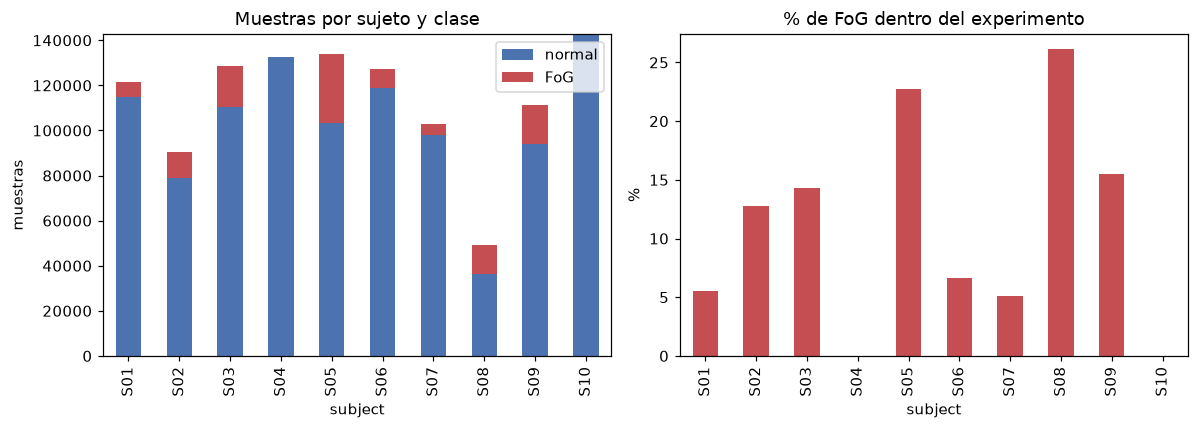

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))

by_subj[["normal", "FoG"]].plot(
    kind="bar", stacked=True, ax=ax[0], color=["#4C72B0", "#C44E52"]
)
ax[0].set_title("Muestras por sujeto y clase")
ax[0].set_ylabel("muestras")

by_subj["%FoG"].plot(kind="bar", ax=ax[1], color="#C44E52")
ax[1].set_title("% de FoG dentro del experimento")
ax[1].set_ylabel("%")

plt.tight_layout()
plt.show()

## 2. Preparación de los datos

Esta sección transforma la señal cruda a los features que consumirá el modelo.


### 2.1. Preprocesamiento

Se descartan las muestras fuera del experimento (etiqueta `0` ), se aplica un filtro Butterworth pasa-bajas de 20 Hz (4º orden, fase cero) sobre los 9 ejes, que es el rango útil del movimiento de marcha, y se identifican los segmentos contiguos del experimento. Al descartar las muestras con etiqueta `0` la grabación queda partida en huecos, tal que cada tramo contiguo se trata como una secuencia independiente y la ventana posterior nunca cruza esos huecos.

La celda siguiente define las funciones que realizan este proceso.


In [10]:
def butter_lp(sig, fs=FS, fc=20, orden=4):
    """
    Filtro Butterworth pasa-bajas filtfilt, sin desfase sobre cada eje.
    fc=20 Hz recorta el ruido por encima del rango útil del movimiento de la marcha.
    """
    b, a = butter(orden, fc / (fs / 2), btype="low")
    return filtfilt(b, a, sig, axis=0)


def contiguous_segments(ann):
    idx = np.where(ann != 0)[0]
    if len(idx) == 0:
        return []
    splits = np.where(np.diff(idx) > 1)[0] + 1
    return np.split(idx, splits)


def build_preprocesado(files_by_subject, fs=FS, path=PREPROCESSED_PATH):
    if path.exists():
        return pickle.load(open(path, "rb"))
    segs = []
    for s, recs in files_by_subject.items():
        for p in recs:
            df = load_recording(p)
            acc = butter_lp(df[AXES].values, fs=fs)
            ann = df[LABEL].values.astype(int)
            for k, seg in enumerate(contiguous_segments(ann)):
                segs.append(
                    {
                        "subject": s,
                        "rec": p.name,
                        "seg_id": k,
                        "acc": acc[seg],
                        "ann": ann[seg],
                    }
                )
    pickle.dump(segs, open(path, "wb"))
    return segs

In [11]:
segmentos = build_preprocesado(files_by_subject)
print(
    "Segmentos contiguos:",
    len(segmentos),
    "| muestras totales:",
    sum(len(x["ann"]) for x in segmentos),
)

Segmentos contiguos: 35 | muestras totales: 1140835


### 2.2 Ventaneo

La señal se divide en ventanas de 3 segundos (192 muestras a 64 Hz) con un paso de 1.5 segundos, (solape 50%). La duración de 3 segundos da una resolución en frecuencia suficiente para separar la banda locomotora (0.5 a 3 Hz) de la banda de freezing (3 a 8 Hz), el solapamiento del 50% es el balance habitual entre resolución temporal y cantidad de ventanas. El ventaneo se aplica dentro de cada segmento contiguo, de modo que ninguna ventana mezcla tramos separados por huecos ni cruza la frontera entre sujetos.


In [12]:
WIN = 64 * 4  # ventana de 3s a 64 Hz
STEP = WIN * 0.5  # paso de 1.5s (50% solape)

### 2.3. Extracción de features

Por cada ventana y por sensor, se calcula la magnitud `‖(x,y,z)‖` de la aceleración como la norma de sus tres ejes, que es robusta a la orientación del sensor, se le quita la media, se aplica ventana de Hann y se obtiene su periodograma, del que se integran dos bandas para construir dos features por sensor.
El *Freeze Index* es el cociente de la potencia de la banda de freezing entre la de la banda locomotora, `FI = pot[3 a 8 Hz] / pot[0.5 a 3 Hz]` . El Power Index es la potencia total de ambas bandas, `PI = pot[0.5 a 8 Hz]` , y se utiliza para distinguir un freeze de un reposo, dado que el FI por sí solo se vuelve inestable cuando casi no hay movimiento.


In [13]:
FEATS = ["FI_ankle", "PI_ankle", "FI_thigh", "PI_thigh", "FI_trunk", "PI_trunk"]
DEP_FEAT = "FI_ankle"  # feature de la dependencia inter-slice

In [14]:
def band_power(x, lo, hi, fs=FS):
    f, pxx = periodogram(x, fs=fs, window="hann", detrend="constant")
    return pxx[(f >= lo) & (f < hi)].sum()


def window_features(seg_acc, fs=FS):
    """
    Por sensor:
        magnitud ||(x,y,z)||
        FI (banda freeze / banda locomotora)
        PI (potencia total de ambas)
    """
    feats = {}
    for s, axes in SENSORS.items():
        cols = [AXES.index(e) for e in axes]
        m = np.sqrt((seg_acc[:, cols] ** 2).sum(axis=1))
        p_loco = band_power(m, 0.5, 3.0, fs=fs)
        p_freeze = band_power(m, 3.0, 8.0, fs=fs)
        feats[f"FI_{ s}"] = p_freeze / (p_loco + 1e-10)
        feats[f"PI_{ s}"] = p_loco + p_freeze
    return feats


def build_features(segmentos, win=WIN, step=STEP, fs=FS, path=FEATURES_PATH):
    """Ventanea cada segmento contiguo y calcula FI/PI por sensor en cada ventana."""
    if path.exists():
        return pickle.load(open(path, "rb"))
    rows = []
    for seg in segmentos:
        acc, ann = seg["acc"], seg["ann"]
        n_win = (len(ann) - win) // step + 1
        for w in range(n_win):
            i0, i1 = w * step, w * step + win
            feats = window_features(acc[i0:i1], fs=fs)
            base = int(
                np.bincount(ann[i0:i1]).argmax()
            )  # 1 normal, 2 freeze (voto mayoritario)
            rows.append(
                {
                    "subject": seg["subject"],
                    "rec": seg["rec"],
                    "seg_id": seg["seg_id"],
                    "w": w,
                    "start": i0 / fs,
                    "center": (i0 + win / 2) / fs,
                    "base": base,
                    **feats,
                }
            )
    df = pd.DataFrame(rows)
    pickle.dump(df, open(path, "wb"))
    return df

Validamos sobre una ventana, mostrando su espectro y las dos bandas.


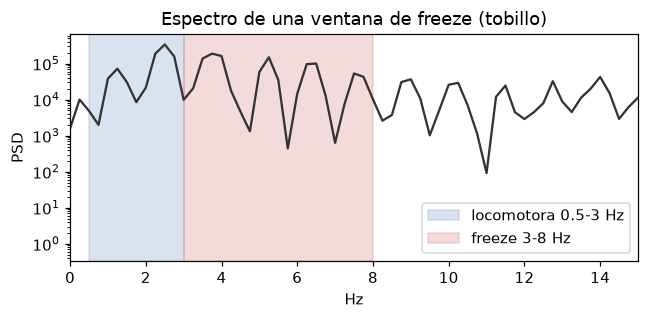

FI/PI de la ventana: {'FI_ankle': np.float64(1.293), 'PI_ankle': np.float64(1981073.014), 'FI_thigh': np.float64(0.975), 'PI_thigh': np.float64(221382.91), 'FI_trunk': np.float64(7.215), 'PI_trunk': np.float64(175291.171)}


In [15]:
ej = next(x for x in segmentos if (x["ann"] == 2).any())
i0 = min(np.where(ej["ann"] == 2)[0][0], len(ej["ann"]) - WIN)
cols_ankle = [AXES.index(e) for e in SENSORS["ankle"]]
m = np.sqrt((ej["acc"][i0 : i0 + WIN, cols_ankle] ** 2).sum(axis=1))
f, pxx = periodogram(m - m.mean(), fs=FS, window="hann", detrend="constant")

plt.figure(figsize=(6, 3))
plt.semilogy(f, pxx, color="#333")
plt.axvspan(0.5, 3, alpha=0.2, color="#4C72B0", label="locomotora 0.5-3 Hz")
plt.axvspan(3, 8, alpha=0.2, color="#C44E52", label="freeze 3-8 Hz")
plt.xlim(0, 15)
plt.xlabel("Hz")
plt.ylabel("PSD")
plt.legend()

plt.title("Espectro de una ventana de freeze (tobillo)")
plt.tight_layout()
plt.show()

print(
    "FI/PI de la ventana:",
    {k: round(v, 3) for k, v in window_features(ej["acc"][i0 : i0 + WIN]).items()},
)

In [16]:
feat_df = build_features(segmentos)

print("Ventanas:", len(feat_df))
display(feat_df[FEATS].describe().round(2))

TypeError: 'float' object cannot be interpreted as an integer

Se muestran las distribuciones de FI y PI por clase base, para ver si los features separan normal de freeze.


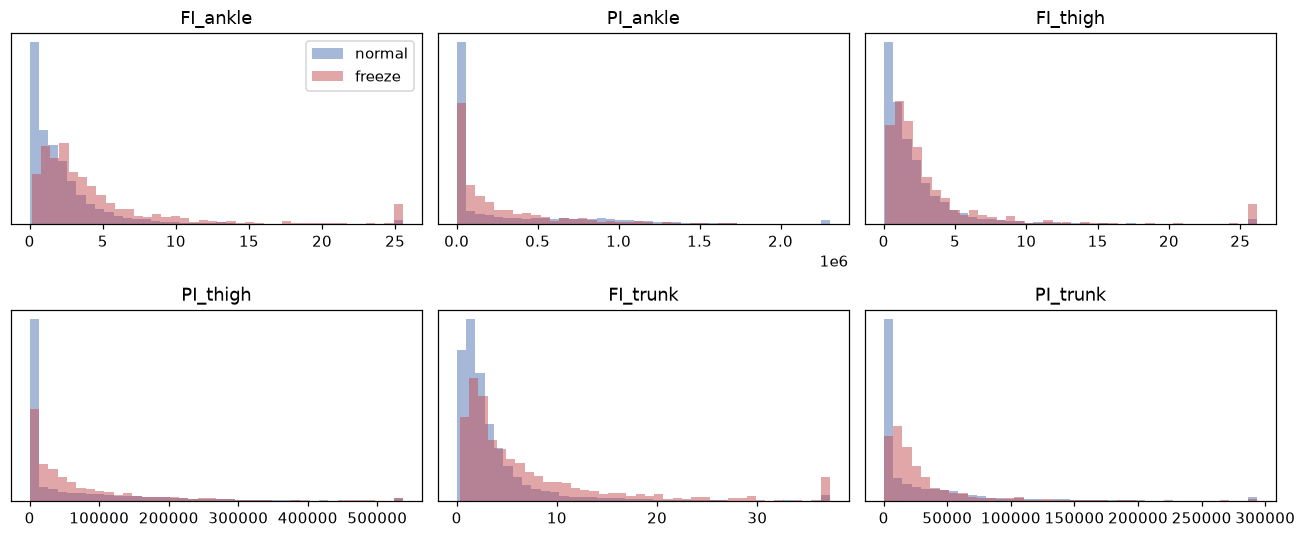

In [ ]:
fig, ax = plt.subplots(2, 3, figsize=(12, 5))

for j, fcol in enumerate(FEATS):
    a = ax[j // 3, j % 3]
    for cl, col, lab in [(1, "#4C72B0", "normal"), (2, "#C44E52", "freeze")]:
        v = feat_df[feat_df.base == cl][fcol].clip(upper=feat_df[fcol].quantile(0.99))
        a.hist(v, bins=40, alpha=0.5, density=True, color=col, label=lab)

    a.set_title(fcol)
    a.set_yticks([])

ax[0, 0].legend()
plt.tight_layout()
plt.show()

### 2.4 Etiquetado

Se comparan dos esquemas de etiquetado. 

* **3 clases**,                  `{normal, pre-FoG, FoG}`, donde el estado pre-FoG se construye con una regla pre-onset que marca como pre-FoG las ventanas normales cuyo centro cae en el intervalo `[onset - τ, onset)`. Los valores de τ provienen de la literatura donde se han evaluado valores entre 2 y 5 segundos. En esta práctica, comparamos `TAU_VALUES = [2, 3, 5]`. 
* **2 clases**,                  `{normal, FoG}`, con las etiquetas originales, sin pre-FoG. Sirve para medir si el tercer estado aporta o no al modelo.


In [ ]:
NORMAL, PREFOG, FOG = 0, 1, 2
GROUP = ["subject", "rec", "seg_id"]
TAU_VALUES = [2, 3, 5]  # ventanas pre-FoG (s) a comparar

In [ ]:
def label_3class(df, tau):
    """
    3 clases. Mapea normal/freeze desde la anotación base y construye pre-FoG con regla pre-onset.
    """
    df = df.copy()
    df["state"] = df["base"].map({1: NORMAL, 2: FOG})
    for _, g in df.groupby(GROUP, sort=False):
        idx, base, start, center = (
            g.index.values,
            g.base.values,
            g.start.values,
            g.center.values,
        )
        for i in range(1, len(idx)):
            if (
                base[i] == ANN_FREEZE and base[i - 1] != ANN_FREEZE
            ):  # onset normal -> freeze
                onset = start[i]
                for j in range(i):
                    if base[j] == 1 and onset - tau <= center[j] < onset:
                        df.at[idx[j], "state"] = PREFOG
    return df


def label_2class(df):
    """2 clases: etiquetas originales sin pre-FoG (0 normal, 1 FoG)."""
    df = df.copy()
    df["state"] = (df["base"] == FOG).astype(int)
    return df

In [ ]:
for tau in TAU_VALUES:
    n = (label_3class(feat_df, tau).state == PREFOG).sum()
    print(f"tau={tau}s -> ventanas pre-FoG: {n}")

tau=2s -> ventanas pre-FoG: 193
tau=3s -> ventanas pre-FoG: 363
tau=5s -> ventanas pre-FoG: 524


## 3. Modelo y algoritmos

### 3.1 Formalización del modelo

El estado oculto `A_t` toma valores en `{normal, pre-FoG, FoG}` para el modelo de tres estados, o en `{normal, FoG}` para la variante de dos estados. En cada corte temporal la observación se descompone en seis atributos discretos, que son el FI y el PI de cada uno de los tres sensores, cada uno cuantizado en `B = 4` bins mediante cuantiles. Esta estructura corresponde a la de un clasificador de red bayesiana dinámica (DBNC).

* **Dependencias**
* - Transición entre estados ocultos: `A_{t-1} → A_t`, cadena de Markov de primer orden.
* - Inter-slice, sobre el FI del tobillo: `O^{FI}_{tobillo,t-1} → O^{FI}_{tobillo,t}`, captura la inercia del FI de un instante al siguiente.

* **Independencias**
* - Dadas `A_t`, las seis observaciones son mutuamente independientes, salvo `O^{FI}_{tobillo}` que depende de su valor previo.

La distribución conjunta se factoriza extendiendo la del DBNC con el término de la dependencia inter-slice:

$$P(A_{1: T}, O_{1: T}) = \pi(A_1)\prod_{t=2}^{T} P(A_t \mid A_{t-1}) \prod_{t=1}^{T}\Big[\prod_{i \neq \mathrm{FI}_{tob}} P(O^{(i)}_t \mid A_t)\Big]\prod_{t} P\big(O^{\mathrm{FI}}_{tob, t} \mid A_t, O^{\mathrm{FI}}_{tob, t-1}\big)$$

* **Parámetros**
* - Distribución Inicial `π` (K); 
* - Matriz de transición `A` (K×K); 
* - Tablas de probabilidad condicional (CPT) de los 5 features sin dependencia inter-slice (K×B); 
* - CPT del FI del tobillo `P(O^{FI}_{tob,t} | A_t, O^{FI}_{tob,t-1})` (K×B×B) más la inicial (K×B)

Todos los parámetoros se estiman por **conteo + suavizado add-k** sobre los datos etiquetados (sin EM, ya que se tienen las etiquetas).


### 3.2 Aprendizaje de parámetros

Las CPT se estiman por conteo con suavizado add-k. Los bordes de cuantiles que discretizan los features se ajustan sobre los datos de entrenamiento.


In [ ]:
B = 4  # número de bins por feature (discretización por cuantiles)
ALPHA = 1.0  # suavizado add-k de las CPT

In [ ]:
def fit_bins(train_df, b=B):
    qs = np.linspace(0, 1, b + 1)[1:-1]
    return {f: np.quantile(train_df[f].values, qs) for f in FEATS}


def discretize(df, edges, b=B):
    """Asigna a cada feature su bin según los bordes ajustados en train; clip acota a [0, b-1]."""
    out = df.copy()
    for f in FEATS:
        out[f + "_b"] = np.clip(np.digitize(df[f].values, edges[f]), 0, b - 1)
    return out


def learn_dbn(train_df, K, alpha=ALPHA, b=B, dep_feat=DEP_FEAT):
    """
    Estima las CPTs del modelo por conteo + suavizado add-k.
    """
    pi = np.full(K, alpha)  # estado inicial
    trans = np.full((K, K), alpha)  # P(A_t | A_{t-1})
    obs_cpt = {
        f: np.full((K, b), alpha) for f in FEATS if f != dep_feat
    }  # P(O^i | A) de los 5 atributos simples

    dep_cpt = np.full((K, b, b), alpha)  # P(FI_tob_t | A_t, FI_tob_{t-1})
    dep_init = np.full((K, b), alpha)  # P(FI_tob | A) en t=1 (sin previo)

    for _, g in train_df.groupby(GROUP, sort=False):
        s = g.state.values
        bn = {f: g[f + "_b"].values for f in FEATS}  # bins discretos por feature
        pi[s[0]] += 1
        dep_init[s[0], bn[dep_feat][0]] += 1
        for t in range(len(g)):
            for f in obs_cpt:
                obs_cpt[f][s[t], bn[f][t]] += 1
            if t:  # consecutivos -> transición y dependencia inter-slice
                trans[s[t - 1], s[t]] += 1
                dep_cpt[s[t], bn[dep_feat][t - 1], bn[dep_feat][t]] += 1

    # normalizacion
    pi /= pi.sum()
    trans /= trans.sum(1, keepdims=True)
    for f in obs_cpt:
        obs_cpt[f] /= obs_cpt[f].sum(1, keepdims=True)

    dep_cpt /= dep_cpt.sum(2, keepdims=True)
    dep_init /= dep_init.sum(1, keepdims=True)

    return dict(
        init=pi, trans=trans, obs_cpt=obs_cpt, dep_cpt=dep_cpt, dep_init=dep_init, K=K
    )

### 3.3 Inferencia

**Viterbi** (max-producto, log) da la secuencia de estados decodificada. **Forward-backward** (suma-producto, log) da las marginales posteriores `P(A_t | O)` para el ROC-AUC. Ambas usan la misma log-probabilidad de observación por instante, donde el término del FI del tobillo se condiciona en su valor previo observado, y en `t = 1` se usa la distribución inicial. Se decodifica por segmento contiguo.


In [ ]:
def logsumexp(a, axis):
    m = a.max(axis, keepdims=True)
    return (m + np.log(np.exp(a - m).sum(axis, keepdims=True))).squeeze(axis)


def log_emissions(g, P, dep_feat=DEP_FEAT):
    """
    log P(observaciones_t | estado) por instante y estado.
    Suma los logs de los 5 atributos independientes y agrega el del FI del tobillo.
    """

    bn = {f: g[f + "_b"].values for f in FEATS}
    T = len(g)
    le = np.zeros((T, P["K"]))
    for f, tab in P["obs_cpt"].items():
        le += np.log(tab[:, bn[f]]).T
    ab = bn[dep_feat]
    le[0] += np.log(P["dep_init"][:, ab[0]])
    if T > 1:
        le[1:] += np.log(P["dep_cpt"][:, ab[:-1], ab[1:]]).T
    return le


def viterbi(le, P):
    """
    MPE (secuencia de estados más probable)
    """
    T, K = le.shape
    log_init, log_trans = np.log(P["init"]), np.log(P["trans"])

    delta = np.full((T, K), -np.inf)  # mejor log-prob acumulada hasta t en cada estado
    psi = np.zeros((T, K), int)  # backpointers para reconstruir el mejor
    delta[0] = log_init + le[0]

    for t in range(1, T):
        m = delta[t - 1][:, None] + log_trans  # (estado previo, estado actual)
        psi[t] = m.argmax(0)
        delta[t] = m.max(0) + le[t]

    # Backtracking desde el mejor estado final
    path = np.zeros(T, int)
    path[-1] = delta[-1].argmax()
    for t in range(T - 2, -1, -1):
        path[t] = psi[t + 1, path[t + 1]]
    return path


def posteriors(le, P):
    """
    Forward-backward
    """
    T, K = le.shape
    log_init, log_trans = np.log(P["init"]), np.log(P["trans"])
    alpha = np.zeros((T, K))
    beta = np.zeros((T, K))
    alpha[0] = log_init + le[0]

    for t in range(1, T):  # forward
        alpha[t] = logsumexp(alpha[t - 1][:, None] + log_trans, 0) + le[t]

    for t in range(T - 2, -1, -1):  # backward
        beta[t] = logsumexp(log_trans + (le[t + 1] + beta[t + 1])[None, :], 1)

    gamma = alpha + beta
    return np.exp(gamma - logsumexp(gamma, 1)[:, None])

## 4. Evaluación experimental (LOSO)

### 4.1 Protocolo y ejecución

Se utiliza Leave-One-Subject-Out: Por cada sujeto *test* se ajustan los bins y las CPT solo sobre los sujetos de entrenamiento, se decodifica el sujeto *test* y se acumulan las predicciones.

Se añaden baselines Random Forest y SVM-RBF que utilizan los mismos seis features continuos, estandarizados por fold, y clasifican cada ventana a ventana sin modelado temporal.


Las celdas siguientes definen las funciones de evaluación, un panel de parámetros para experimentación rápida, y finalmente ejecutan toda la matriz de comparación.


In [ ]:
def loso_dbn(
    df, K, fog_idx, pre_idx=None, b=B, alpha=ALPHA, dep_feat=DEP_FEAT, desc=""
):
    y_true, y_pred, fs, prs = [], [], [], []
    t_train = t_infer = 0.0  # tiempos acumulados sobre todos los folds (segundos)
    for ts in tqdm(sorted(df.subject.unique()), desc=desc, leave=False):
        train, eval = df[df.subject != ts], df[df.subject == ts]

        t0 = time.perf_counter()
        edges = fit_bins(train, b=b)  # bins
        P = learn_dbn(
            discretize(train, edges, b=b), K, alpha=alpha, b=b, dep_feat=dep_feat
        )
        t_train += time.perf_counter() - t0

        t0 = time.perf_counter()
        for _, g in discretize(eval, edges, b=b).groupby(GROUP, sort=False):
            le = log_emissions(g, P, dep_feat=dep_feat)
            pp = posteriors(le, P)
            y_pred.extend(viterbi(le, P))  # etiqueta hard (Viterbi)
            fs.extend(pp[:, fog_idx])  # score continuo de FoG (posterior) para AUC

            prs.extend(pp[:, pre_idx] if pre_idx is not None else [np.nan] * len(g))
            y_true.extend(g.state.values)
        t_infer += time.perf_counter() - t0

    arrs = tuple(map(np.array, [y_true, y_pred, fs, prs]))
    return arrs + (t_train, t_infer)


def loso_ml(df, kind, K, fog_idx, desc=""):
    y_true, y_pred, fs = [], [], []
    t_train = t_infer = 0.0
    for ts in tqdm(sorted(df.subject.unique()), desc=desc, leave=False):
        train, eval = df[df.subject != ts], df[df.subject == ts]

        t0 = time.perf_counter()
        sc = StandardScaler().fit(train[FEATS])
        Xtr = sc.transform(train[FEATS])
        clf = (
            RandomForestClassifier(
                n_estimators=100, class_weight="balanced", random_state=0, n_jobs=-1
            )
            if kind == "RF"
            else SVC(kernel="rbf", class_weight="balanced", random_state=0)
        )
        clf.fit(Xtr, train.state)
        t_train += time.perf_counter() - t0

        t0 = time.perf_counter()
        Xte = sc.transform(eval[FEATS])
        y_pred.extend(clf.predict(Xte))
        clases = list(clf.classes_)

        # Score de FoG para el AUC: probabilidad en RF, función de decisión en SVM.
        if kind == "RF":
            pr = clf.predict_proba(Xte)
            fs.extend(
                pr[:, clases.index(fog_idx)]
                if fog_idx in clases
                else np.zeros(len(eval))
            )
        else:
            dec = clf.decision_function(Xte)
            fs.extend(dec[:, clases.index(fog_idx)] if K > 2 else dec)
        t_infer += time.perf_counter() - t0

        y_true.extend(eval.state.values)

    arrs = tuple(map(np.array, [y_true, y_pred, fs]))
    return arrs + (t_train, t_infer)

In [ ]:
def sens_spec(M, c):
    tp = M[c, c]
    fn = M[c].sum() - tp
    fp = M[:, c].sum() - tp
    tn = M.sum() - tp - fn - fp
    return tp / (tp + fn + 1e-9), tn / (tn + fp + 1e-9)


def evaluate(
    nombre,
    variante,
    y_true,
    y_pred,
    fs,
    K,
    fog_idx,
    pre_idx=None,
    prs=None,
    t_train=np.nan,
    t_infer=np.nan,
):
    M = confusion_matrix(y_true, y_pred, labels=list(range(K)))

    tb = y_true == fog_idx
    pb = y_pred == fog_idx

    det_sens = (tb & pb).sum() / (tb.sum() + 1e-9)
    det_spec = (~tb & ~pb).sum() / ((~tb).sum() + 1e-9)

    fog_auc = roc_auc_score(tb.astype(int), fs) if tb.any() and (~tb).any() else np.nan

    pre_auc = (
        roc_auc_score((y_true == pre_idx).astype(int), prs)
        if pre_idx is not None and (y_true == pre_idx).any()
        else np.nan
    )

    return {
        "modelo": nombre,
        "variante": variante,
        "acc": accuracy_score(y_true, y_pred),
        "macroF1": f1_score(y_true, y_pred, average="macro", labels=list(range(K))),
        "MCC": matthews_corrcoef(y_true, y_pred),
        "FoG_sens": det_sens,
        "FoG_spec": det_spec,
        "FoG_AUC": fog_auc,
        "preFoG_AUC": pre_auc,
        "t_train_s": t_train,
        "t_infer_s": t_infer,
        "_cm": M,
        "_y": (tb.astype(int), fs),
    }

In [ ]:
B = 4  # bins por feature
ALPHA = 1.0  # suavizado add-k
DEP_FEAT = "FI_ankle"  # feature con dependencia inter-slice
TAU_VALUES = [3, 4, 5]  # ventanas pre-FoG

In [ ]:
results, store = [], {}

# 3 clases para cada tau
for tau in TAU_VALUES:
    df3 = label_3class(feat_df, tau)
    variante = f"3 clases tau={tau}"
    y_true, y_pred, fs, prs, t_train, t_infer = loso_dbn(
        df3, 3, FOG, PREFOG, b=B, alpha=ALPHA, dep_feat=DEP_FEAT, desc=f"DBN {variante}"
    )
    r = evaluate(
        "DBN (3 estados)",
        variante,
        y_true,
        y_pred,
        fs,
        3,
        FOG,
        PREFOG,
        prs,
        t_train,
        t_infer,
    )
    results.append(r)
    store[r["modelo"], r["variante"]] = r

    for k in ["RF", "SVM"]:
        y_true, y_pred, fs, t_train, t_infer = loso_ml(
            df3, k, 3, FOG, desc=f"{k} {variante}"
        )
        r = evaluate(
            k, variante, y_true, y_pred, fs, 3, FOG, t_train=t_train, t_infer=t_infer
        )
        results.append(r)
        store[r["modelo"], r["variante"]] = r

DBN 3 clases tau=3:   0%|          | 0/10 [00:00<?, ?it/s]

RF 3 clases tau=3:   0%|          | 0/10 [00:00<?, ?it/s]

SVM 3 clases tau=3:   0%|          | 0/10 [00:00<?, ?it/s]

DBN 3 clases tau=4:   0%|          | 0/10 [00:00<?, ?it/s]

RF 3 clases tau=4:   0%|          | 0/10 [00:00<?, ?it/s]

SVM 3 clases tau=4:   0%|          | 0/10 [00:00<?, ?it/s]

DBN 3 clases tau=5:   0%|          | 0/10 [00:00<?, ?it/s]

RF 3 clases tau=5:   0%|          | 0/10 [00:00<?, ?it/s]

SVM 3 clases tau=5:   0%|          | 0/10 [00:00<?, ?it/s]

In [ ]:
# 2 clases (sin pre-FoG)
df2 = label_2class(feat_df)
y_true, y_pred, fs, _, t_train, t_infer = loso_dbn(
    df2, 2, 1, b=B, alpha=ALPHA, dep_feat=DEP_FEAT, desc="DBN 2 clases"
)
r = evaluate(
    "DBN (2 estados)",
    "2 clases",
    y_true,
    y_pred,
    fs,
    2,
    1,
    t_train=t_train,
    t_infer=t_infer,
)
results.append(r)
store[r["modelo"], r["variante"]] = r

for k in ["RF", "SVM"]:
    y_true, y_pred, fs, t_train, t_infer = loso_ml(df2, k, 2, 1, desc=f"{k} 2 clases")
    r = evaluate(
        k, "2 clases", y_true, y_pred, fs, 2, 1, t_train=t_train, t_infer=t_infer
    )
    results.append(r)
    store[r["modelo"], r["variante"]] = r

DBN 2 clases:   0%|          | 0/10 [00:00<?, ?it/s]

RF 2 clases:   0%|          | 0/10 [00:00<?, ?it/s]

SVM 2 clases:   0%|          | 0/10 [00:00<?, ?it/s]

In [ ]:
print("Configuraciones evaluadas:", len(results))

Configuraciones evaluadas: 12


### 4.2 Métricas y resultados

Las métricas se calculan sobre las predicciones agrupadas de todos los folds. Se incluye accuracy, pero es engañosa debido al desvalance entre clases; las métricas relevantes son la sensibilidad y la especificidad de FoG, macro-F1 y AUC.


In [ ]:
tab = pd.DataFrame(
    [{k: v for k, v in r.items() if not k.startswith("_")} for r in results]
)
tab = tab[
    [
        "variante",
        "modelo",
        "acc",
        "macroF1",
        "MCC",
        "FoG_sens",
        "FoG_spec",
        "FoG_AUC",
        "preFoG_AUC",
        "t_train_s",
        "t_infer_s",
    ]
]
display(tab.round(3))

,variante,modelo,acc,macroF1,MCC,FoG_sens,FoG_spec,FoG_AUC,preFoG_AUC,t_train_s,t_infer_s
0,3 clases tau=3,DBN (3 estados),0.551,0.395,0.250,0.568,0.865,0.851,0.650,0.698,0.429
1,3 clases tau=3,RF,0.844,0.474,0.370,0.571,0.902,0.865,NaN,4.375,0.906
2,3 clases tau=3,SVM,0.550,0.352,0.132,0.468,0.806,0.688,NaN,68.797,16.929
3,3 clases tau=4,DBN (3 estados),0.551,0.395,0.250,0.568,0.865,0.851,0.650,0.594,0.441
4,3 clases tau=4,RF,0.844,0.474,0.370,0.571,0.902,0.865,NaN,4.029,0.798
5,3 clases tau=4,SVM,0.550,0.352,0.132,0.468,0.806,0.688,NaN,65.206,16.171
6,3 clases tau=5,DBN (3 estados),0.549,0.411,0.264,0.534,0.886,0.851,0.668,0.509,0.384
7,3 clases tau=5,RF,0.827,0.470,0.350,0.570,0.901,0.865,NaN,3.458,0.734
8,3 clases tau=5,SVM,0.531,0.355,0.130,0.480,0.802,0.692,NaN,64.043,16.612
9,2 clases,DBN (2 estados),0.756,0.620,0.368,0.832,0.748,0.853,NaN,0.571,0.471


In [ ]:
labs3, labs2 = ["normal", "pre-FoG", "FoG"], ["normal", "FoG"]


def plot_confusions(keys, suptitle=None):
    fig, axes = plt.subplots(1, len(keys), figsize=(4.3 * len(keys), 3.8))
    axes = np.atleast_1d(axes)
    for ax, key in zip(axes, keys):
        r = store[key]
        M = r["_cm"]
        L = labs3 if M.shape[0] == 3 else labs2
        Mn = M / M.sum(1, keepdims=True)
        sns.heatmap(
            Mn,
            annot=True,
            fmt=".2f",
            cmap="Blues",
            vmin=0,
            vmax=1,
            xticklabels=L,
            yticklabels=L,
            cbar=False,
            square=True,
            ax=ax,
        )
        ax.set_title(f"{r['modelo']}, {r['variante']}", fontsize=9)
        ax.set_xlabel("predicho")
        ax.set_ylabel("real")
    if suptitle:
        fig.suptitle(suptitle, y=1.04)
    plt.tight_layout()
    plt.show()

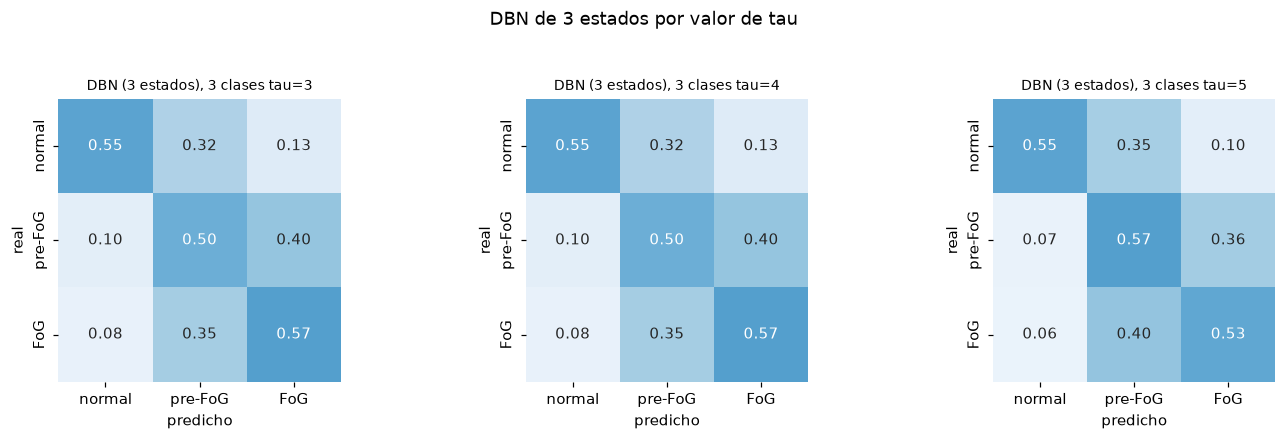

In [ ]:
keys = [("DBN (3 estados)", f"3 clases tau={tau}") for tau in TAU_VALUES]
plot_confusions(keys, suptitle="DBN de 3 estados por valor de tau")

Mejor tau (3 clases) por macro-F1: 3 clases tau=5


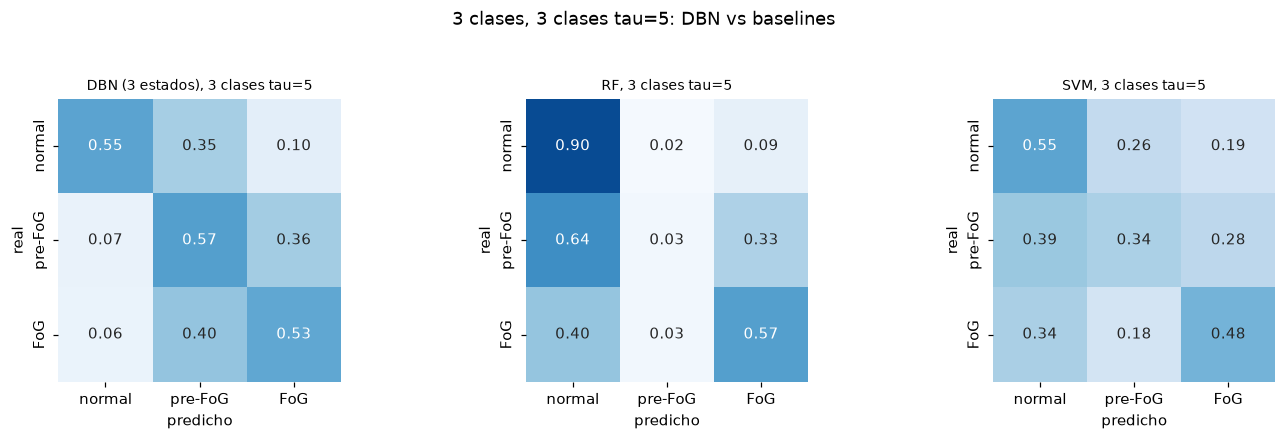

In [ ]:
# Mejor tau (3 clases), elegido por macro-F1 del DBN, comparado contra RF y SVM.
dbn_3c = [r for r in results if r["modelo"] == "DBN (3 estados)"]
mejor_esquema = max(dbn_3c, key=lambda r: r["macroF1"])["variante"]

print("Mejor tau (3 clases) por macro-F1:", mejor_esquema)
keys = [(m, mejor_esquema) for m in ["DBN (3 estados)", "RF", "SVM"]]
plot_confusions(keys, suptitle=f"3 clases, {mejor_esquema}: DBN vs baselines")

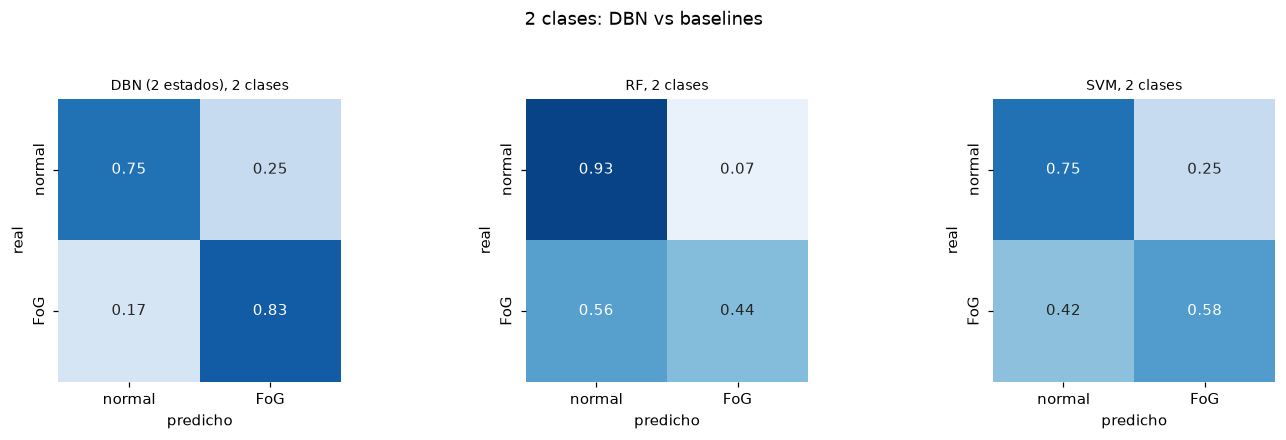

In [ ]:
# 2 clases: DBN vs baselines.
keys = [(m, "2 clases") for m in ["DBN (2 estados)", "RF", "SVM"]]
plot_confusions(keys, suptitle="2 clases: DBN vs baselines")

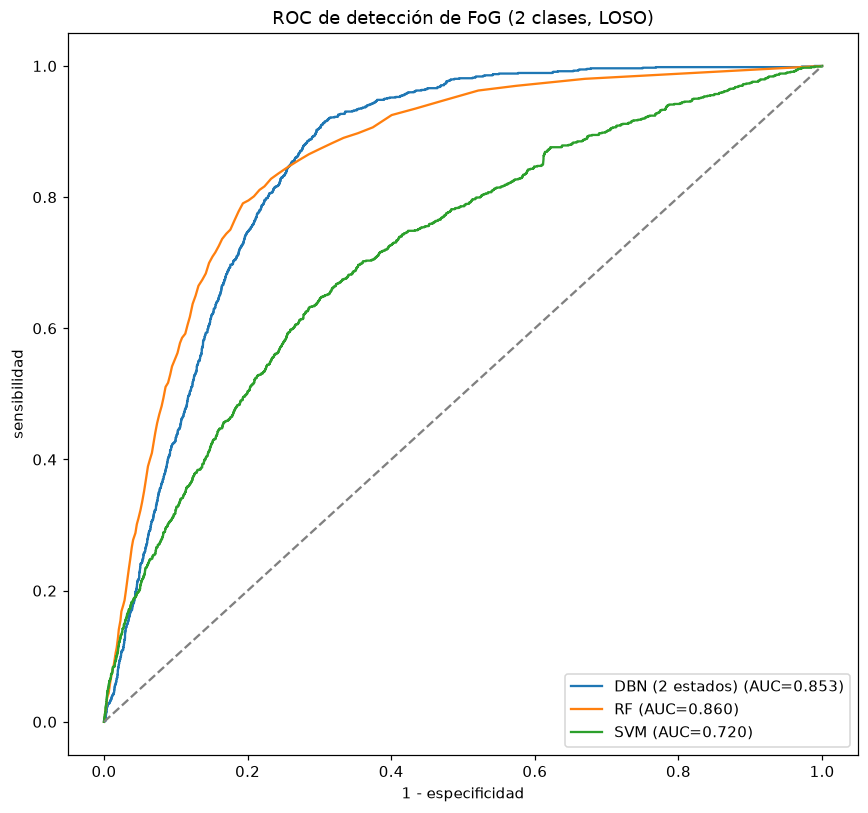

In [ ]:
# Curvas ROC AUC
plt.figure(figsize=(8, 7.5))
for nombre in ["DBN (2 estados)", "RF", "SVM"]:
    yb, sc = store[nombre, "2 clases"]["_y"]
    fpr, tpr, _ = roc_curve(yb, sc)
    auc = roc_auc_score(yb, sc)
    plt.plot(fpr, tpr, label=f"{nombre} (AUC={auc:.3f})")
plt.plot([0, 1], [0, 1], "--", color="gray")
plt.xlabel("1 - especificidad")
plt.ylabel("sensibilidad")
plt.title("ROC de detección de FoG (2 clases, LOSO)")
plt.legend()
plt.tight_layout()
plt.show()